# Matching Anomalies to Astronomical Intuition

In [1]:
import os

# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.constants import GALAXY_LINES
from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import specobjid_to_idx

# from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra.notebook import explain_reconstruction_score
from astroExplain.spectra.explanation import TellMeWhy

from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Explanation name

In [3]:
def explanation_name(lime_config: dict, fudge_config: dict) -> str:

    segmentation = lime_config["segmentation"]
    n_segments = lime_config["number_segments"]
    perturbation = fudge_config["kind_of_fudge"]

    explanation_str = f"{segmentation}_{n_segments}_{perturbation}"

    if perturbation == "scale":

        scale_factor = fudge_config["scale_factor"]
        explanation_str = f"{explanation_str}_{scale_factor}"

    return explanation_str

## Lime weights

In [4]:
def get_weights(
    wave,
    explanation,
    max_normalization=True,
) -> tuple:

    why = TellMeWhy(wave=wave, explanation=explanation)
    weights = why.get_heatmap()

    if max_normalization is True:
        weights = np.abs(weights) / np.nanmax(np.abs(weights))

    return weights

# Config

## LIME constants

In [ ]:
lime_config = {
    "segmentation": "uniform",
    "number_segments": 150,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10_000,
}

fudge_config = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

Segment width: 25, Last segment width: 23


## Directories

In [5]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

## Data

In [6]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

In [75]:
n_segments = 150
segment_width = wave.shape[0] // n_segments
last_segment_width = wave.shape[0] % n_segments
print(f"Segment width: {segment_width}, Last segment width: {last_segment_width}")

Segment width: 25, Last segment width: 23


## Load model

In [8]:
bin_id = "bin_03"
ae_model_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

# Distinct Residual based anomalies sample

## Data prep

In [9]:
bin_id = "bin_03"

overview_distinct_dict = {
    "SE": 2201231682403592192,
    "Filter SE": 2203468363479410688,
    "Trim SE": 312016418084251648,
    "Filter + Trim SE": 2191010072388200448,
    "RSE": 1534667320067123200,
    "Filter RSE": 2032375840699869184,
    "Trim RSE": 1781231151415846912,
    "Filter + Trim RSE": 2486018670363437056,
}

spec_overview_distinct_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/res_distinct_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key in overview_distinct_dict.keys():

    objid = overview_distinct_dict[key]
    spec_idx = specobjid_to_idx(objid, idx_id_spec)

    spec_overview_distinct_dict[key] = spectra[spec_idx]

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[objid].values
    # get_sdss_spec_img(
    #     specobjid=objid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_overview_distinct_dict = {}

for key in overview_distinct_dict.keys():

    objid = overview_distinct_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_overview_distinct_dict[key] = img_

Get specs and load photometry


Segment width: 25, Last segment width: 23


# SE Explanations

In [ ]:
score_config = {
    "metric": "mse",
    "velocity": None,
    "relative": False,
    "percentage": None,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

xai_se_dict = {}

for key in overview_distinct_dict.keys():

    specobjid = overview_distinct_dict[key]
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    if key == "SE":
        score_config["velocity"] = 0
        score_config["percentage"] = 100

    elif key == "Filter SE":
        score_config["velocity"] = 250
        score_config["percentage"] = 100

    elif key == "Trim SE":
        score_config["velocity"] = 0
        score_config["percentage"] = 97

    elif key == "Filter + Trim SE":

        score_config["velocity"] = 250
        score_config["percentage"] = 97

    else:
        continue

    explanation, _, _ = explain_reconstruction_score(
        wave=wave,
        spectrum=spectrum,
        score_config=score_config,
        lime_config=lime_config,
        fudge_config=fudge_config,
        model=ae_model_03,
    )

    xai_se_dict[key] = get_weights(
        wave=wave_nm,
        explanation=explanation,
        max_normalization=True,
    )

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


## Figure

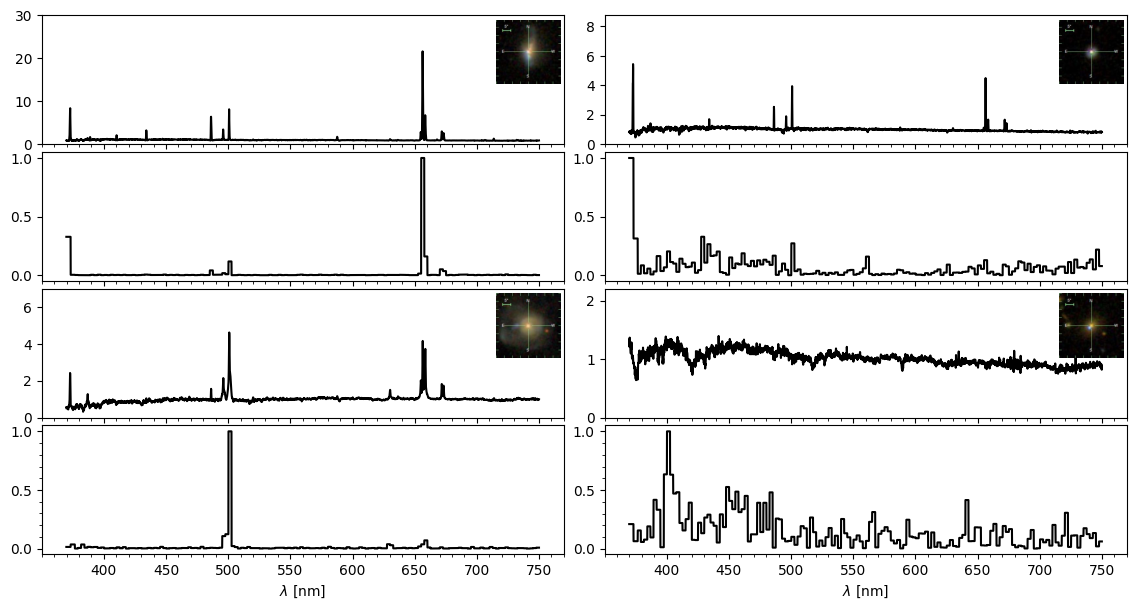

In [42]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))

width_height_image = "100%"

# -------------------------------------------------------------------------------------
# SE
# -------------------------------------------------------------------------------------
axs[0, 0], ax_img = spec_photo_thumbnail(
    axs[0, 0],
    wave_nm,
    spec_overview_distinct_dict["SE"],
    img_overview_distinct_dict["SE"],
    width_height_image=width_height_image,
    add_image=True,
)
axs[1, 0], _ = spec_photo_thumbnail(
    axs[1, 0],
    wave_nm,
    xai_se_dict["SE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)
# -------------------------------------------------------------------------------------
# Filter SE
# -------------------------------------------------------------------------------------
axs[2, 0], ax_img = spec_photo_thumbnail(
    axs[2, 0],
    wave_nm,
    spec_overview_distinct_dict["Filter SE"],
    img_overview_distinct_dict["Filter SE"],
    width_height_image=width_height_image,
    add_image=True,
)
axs[3, 0], _ = spec_photo_thumbnail(
    axs[3, 0],
    wave_nm,
    xai_se_dict["Filter SE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)
# -------------------------------------------------------------------------------------
# Trim SE
# -------------------------------------------------------------------------------------
axs[0, 1], ax_img = spec_photo_thumbnail(
    axs[0, 1],
    wave_nm,
    spec_overview_distinct_dict["Trim SE"],
    img_overview_distinct_dict["Trim SE"],
    width_height_image=width_height_image,
    add_image=True,
)
axs[1, 1], _ = spec_photo_thumbnail(
    axs[1, 1],
    wave_nm,
    xai_se_dict["Trim SE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)
# -------------------------------------------------------------------------------------
# Filter + Trim SE
# -------------------------------------------------------------------------------------
axs[2, 1], ax_img = spec_photo_thumbnail(
    axs[2, 1],
    wave_nm,
    spec_overview_distinct_dict["Filter + Trim SE"],
    img_overview_distinct_dict["Filter + Trim SE"],
    width_height_image=width_height_image,
    add_image=True,
)
axs[3, 1], _ = spec_photo_thumbnail(
    axs[3, 1],
    wave_nm,
    xai_se_dict["Filter + Trim SE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)

# -------------------------------------------------------------------------------------
# spec settings
# -------------------------------------------------------------------------------------
# SE
axs[0, 0].set_ylim(0, 30)
flux_ticks = range(0, 31, 10)
axs[0, 0].set_yticks(flux_ticks)
# Filter SE
axs[2, 0].set_ylim(0, 7)
flux_ticks = range(0, 7, 2)
axs[2, 0].set_yticks(flux_ticks)
# Trim SE
axs[0, 1].set_ylim(0, 8.75)
flux_ticks = range(0, 9, 2)
axs[0, 1].set_yticks(flux_ticks)
# Filter + Trim SE
axs[2, 1].set_ylim(0, 2.2)
flux_ticks = [0, 1, 2]
axs[2, 1].set_yticks(flux_ticks)
# -------------------------------------------------------------------------------------
# axes settings
# -------------------------------------------------------------------------------------
axs[3, 0].set_xlim(350, 770)
axs[3, 1].set_xlim(350, 770)
wave_ticks = list(np.arange(400, 751, 50))
axs[3, 0].set_xticks(wave_ticks)
axs[3, 1].set_xticks(wave_ticks)
axs[3, 0].minorticks_on()
axs[3, 1].minorticks_on()
axs[3, 0].set_xlabel(r"$\lambda$ [nm]")
axs[3, 1].set_xlabel(r"$\lambda$ [nm]")
plt.subplots_adjust(hspace=0.06, wspace=0.078)

# RSE explanations

In [ ]:
score_config = {
    "metric": "mse",
    "velocity": None,
    "relative": True,
    "percentage": None,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

xai_rse_dict = {}

for key in overview_distinct_dict.keys():

    specobjid = overview_distinct_dict[key]
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    if key == "RSE":
        score_config["velocity"] = 0
        score_config["percentage"] = 100

    elif key == "Filter RSE":
        score_config["velocity"] = 250
        score_config["percentage"] = 100

    elif key == "Trim RSE":
        score_config["velocity"] = 0
        score_config["percentage"] = 97

    elif key == "Filter + Trim RSE":

        score_config["velocity"] = 250
        score_config["percentage"] = 97
    else:
        continue

    explanation, _, _ = explain_reconstruction_score(
        wave=wave,
        spectrum=spectrum,
        score_config=score_config,
        lime_config=lime_config,
        fudge_config=fudge_config,
        model=ae_model_03,
    )

    xai_rse_dict[key] = get_weights(
        wave=wave_nm,
        explanation=explanation,
        max_normalization=True,
    )

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


## Figure

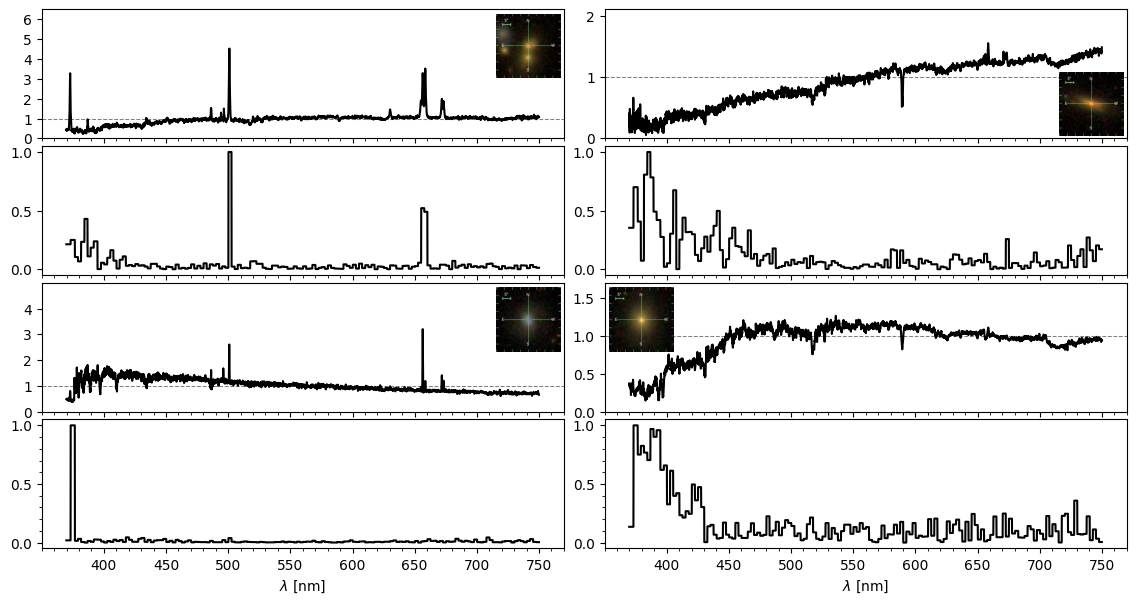

In [51]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))

width_height_image = "100%"

# -------------------------------------------------------------------------------------
# RSE
# -------------------------------------------------------------------------------------
axs[0, 0], ax_img = spec_photo_thumbnail(
    axs[0, 0],
    wave_nm,
    spec_overview_distinct_dict["RSE"],
    img_overview_distinct_dict["RSE"],
    width_height_image=width_height_image,
    add_image=True,
)
axs[1, 0], _ = spec_photo_thumbnail(
    axs[1, 0],
    wave_nm,
    xai_rse_dict["RSE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)
# -------------------------------------------------------------------------------------
# Filter RSE
# -------------------------------------------------------------------------------------
axs[2, 0], ax_img = spec_photo_thumbnail(
    axs[2, 0],
    wave_nm,
    spec_overview_distinct_dict["Filter RSE"],
    img_overview_distinct_dict["Filter RSE"],
    width_height_image=width_height_image,
    add_image=True,
)
axs[3, 0], _ = spec_photo_thumbnail(
    axs[3, 0],
    wave_nm,
    xai_rse_dict["Filter RSE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)
# -------------------------------------------------------------------------------------
# Trim RSE
# -------------------------------------------------------------------------------------
axs[0, 1], ax_img = spec_photo_thumbnail(
    axs[0, 1],
    wave_nm,
    spec_overview_distinct_dict["Trim RSE"],
    img_overview_distinct_dict["Trim RSE"],
    width_height_image=width_height_image,
    bbox_to_anchor=(0.695, 0.07, 0.5, 0.5),
    add_image=True,
)
axs[1, 1], _ = spec_photo_thumbnail(
    axs[1, 1],
    wave_nm,
    xai_rse_dict["Trim RSE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)
# -------------------------------------------------------------------------------------
# Filter + Trim RSE
# -------------------------------------------------------------------------------------
axs[2, 1], ax_img = spec_photo_thumbnail(
    axs[2, 1],
    wave_nm,
    spec_overview_distinct_dict["Filter + Trim RSE"],
    img_overview_distinct_dict["Filter + Trim RSE"],
    width_height_image=width_height_image,
    bbox_to_anchor=(-0.167, 0.52, 0.5, 0.5),
    add_image=True,
)
axs[3, 1], _ = spec_photo_thumbnail(
    axs[3, 1],
    wave_nm,
    xai_rse_dict["Filter + Trim RSE"],
    None,
    width_height_image=width_height_image,
    add_image=False,
)

# -------------------------------------------------------------------------------------
# spec settings
# -------------------------------------------------------------------------------------
# RSE
axs[0, 0].set_ylim(0, 6.5)
flux_ticks = range(0, 7, 1)
axs[0, 0].set_yticks(flux_ticks)

# Filter RSE
axs[2, 0].set_ylim(0, 5)
flux_ticks = [0, 1, 2, 3, 4]
axs[2, 0].set_yticks(flux_ticks)

# Trim RSE
axs[0, 1].set_ylim(0, 2.1)
flux_ticks = [0, 1, 2]
axs[0, 1].set_yticks(flux_ticks)

# Filter + Trim RSE
axs[2, 1].set_ylim(0, 1.7)
flux_ticks = [0, 0.5, 1, 1.5]
axs[2, 1].set_yticks(flux_ticks)

# Horizontal line at 1 for all spectra
for i, j in [(0, 0), (2, 0), (0, 1), (2, 1)]:
    axs[i, j].axhline(
        y=1, color="black", linestyle="--", linewidth=0.75, zorder=5, alpha=0.5
    )
# -------------------------------------------------------------------------------------
# axes settings
# -------------------------------------------------------------------------------------
axs[3, 0].set_xlim(350, 770)
axs[3, 1].set_xlim(350, 770)
wave_ticks = list(np.arange(400, 751, 50))
axs[3, 0].set_xticks(wave_ticks)
axs[3, 1].set_xticks(wave_ticks)
axs[3, 0].minorticks_on()
axs[3, 1].minorticks_on()
axs[3, 0].set_xlabel(r"$\lambda$ [nm]")
axs[3, 1].set_xlabel(r"$\lambda$ [nm]")
plt.subplots_adjust(hspace=0.06, wspace=0.078)